# ⚡ Smart City Digital Twin — Multi-Scenario Inferences & Predictions

This notebook runs **multiple scenario simulations, batch inferences, and what-if stress tests** using your trained **RandomForestRegressor** model (`smart_city_randomforest_model.joblib`).

--- 
### Table of Contents
1. **Load Trained Model & Artifacts**
2. **Scenario A: Baseline Single Inferences**
3. **Scenario B: 24-Hour Hourly Grid Demand Simulation**
4. **Scenario C: Extreme Heatwave & Temperature Stress Test**
5. **Scenario D: Multi-District Comparative Inferences (20 Districts)**
6. **Scenario E: Batch Prediction on CSV & Export Results**
7. **Scenario F: Direct Inference via Decisera Live REST API**

In [1]:
# 1. Setup imports
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (12, 6)

# Path to model
model_path = "/app/models/smart_city_randomforest_model.joblib"
if not os.path.exists(model_path):
    model_path = "./models/smart_city_randomforest_model.joblib"

print(f"Loading model from: {model_path}")
model = joblib.load(model_path)
print(f"✅ Successfully loaded: {type(model).__name__}")
print(f"Expected feature count: {len(model.feature_names_in_)}")
expected_features = list(model.feature_names_in_)

Loading model from: /app/models/smart_city_randomforest_model.joblib


✅ Successfully loaded: RandomForestRegressor
Expected feature count: 123


In [2]:
# Helper function to construct aligned DataFrame for predictions
def predict_scenarios(scenario_dicts):
    df = pd.DataFrame(scenario_dicts)
    
    # Reindex aligns the columns to expected_features.
    # It adds missing columns with 0.0 and drops any extra columns not in expected_features.
    df_aligned = df.reindex(columns=expected_features, fill_value=0.0)
    
    predictions = model.predict(df_aligned)
    return predictions

### 📈 Scenario A: Baseline Weather & Grid Variations
Testing electricity demand across varying solar output and temperatures.

,case,temperature_c,solar_generation_mwh,base_electricity_demand_mwh,predicted_demand_mwh
0,Sunny Summer Peak,36.0,180.0,160.0,84.233650
1,Mild Spring Day,21.0,90.0,95.0,79.479292
2,Cold Winter Morning,2.0,15.0,180.0,89.092547
3,Overcast Autumn Day,14.0,25.0,110.0,83.899035


/tmp/ipykernel_763/722989438.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x="case", y="predicted_demand_mwh", palette="coolwarm")


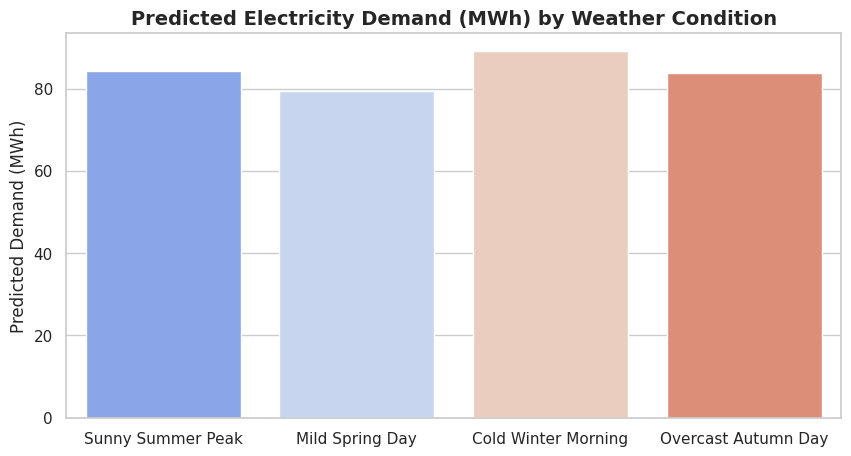

In [3]:
test_cases = [
    {"case": "Sunny Summer Peak", "temperature_c": 36.0, "solar_generation_mwh": 180.0, "base_electricity_demand_mwh": 160.0, "population": 150000},
    {"case": "Mild Spring Day", "temperature_c": 21.0, "solar_generation_mwh": 90.0, "base_electricity_demand_mwh": 95.0, "population": 150000},
    {"case": "Cold Winter Morning", "temperature_c": 2.0, "solar_generation_mwh": 15.0, "base_electricity_demand_mwh": 180.0, "population": 150000},
    {"case": "Overcast Autumn Day", "temperature_c": 14.0, "solar_generation_mwh": 25.0, "base_electricity_demand_mwh": 110.0, "population": 150000},
]

preds = predict_scenarios(test_cases)
res_df = pd.DataFrame(test_cases)
res_df["predicted_demand_mwh"] = preds

display(res_df[["case", "temperature_c", "solar_generation_mwh", "base_electricity_demand_mwh", "predicted_demand_mwh"]])

plt.figure(figsize=(10, 5))
sns.barplot(data=res_df, x="case", y="predicted_demand_mwh", palette="coolwarm")
plt.title("Predicted Electricity Demand (MWh) by Weather Condition", fontsize=14, fontweight="bold")
plt.ylabel("Predicted Demand (MWh)")
plt.xlabel("")
plt.show()

### ⏰ Scenario B: 24-Hour Grid Demand Simulation
Simulating hourly demand progression through morning peak, solar peak, and evening cooling demand.

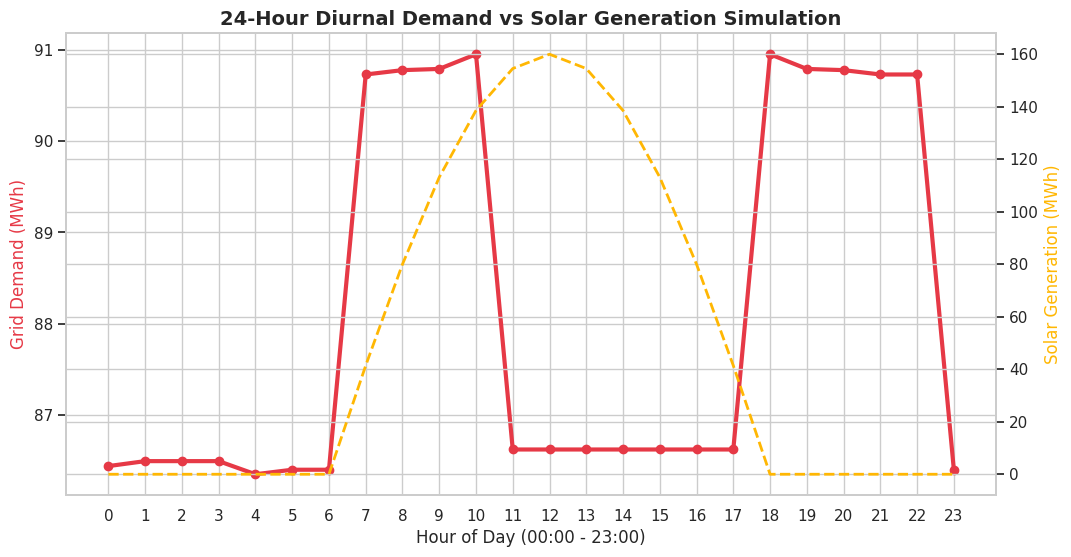

In [4]:
hours = list(range(24))
hourly_scenarios = []

for h in hours:
    # Synthetic diurnal curve
    temp = 20.0 + 10.0 * np.sin((h - 8) / 24.0 * 2 * np.pi)
    solar = max(0.0, 160.0 * np.sin((h - 6) / 12.0 * np.pi)) if 6 <= h <= 18 else 0.0
    base_demand = 80.0 + (50.0 if (7 <= h <= 10 or 18 <= h <= 22) else 10.0)
    
    scenario = {
        "hour": h,
        f"hour_{h}": 1,
        "temperature_c": temp,
        "solar_generation_mwh": solar,
        "base_electricity_demand_mwh": base_demand,
        "grid_capacity_mwh_x": 450.0,
        "population": 120000
    }
    hourly_scenarios.append(scenario)

hourly_preds = predict_scenarios(hourly_scenarios)
hourly_df = pd.DataFrame(hourly_scenarios)
hourly_df["predicted_demand_mwh"] = hourly_preds

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(hourly_df["hour"], hourly_df["predicted_demand_mwh"], color="#E63946", linewidth=3, marker="o", label="Predicted Grid Demand (MWh)")
ax2.plot(hourly_df["hour"], hourly_df["solar_generation_mwh"], color="#FFB703", linestyle="--", linewidth=2, label="Solar Output (MWh)")

ax1.set_xlabel("Hour of Day (00:00 - 23:00)", fontsize=12)
ax1.set_ylabel("Grid Demand (MWh)", color="#E63946", fontsize=12)
ax2.set_ylabel("Solar Generation (MWh)", color="#FFB703", fontsize=12)
plt.title("24-Hour Diurnal Demand vs Solar Generation Simulation", fontsize=14, fontweight="bold")
plt.xticks(hours)
plt.show()

### 🔥 Scenario C: Extreme Heatwave & Climate Shock Simulation
Evaluating grid load stress as ambient temperature increases from 15°C to 45°C.

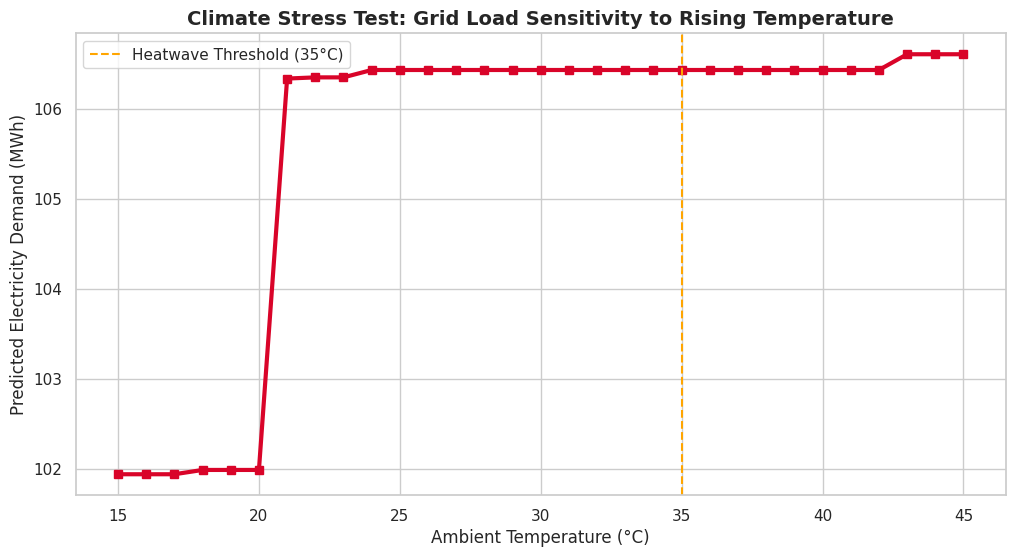

In [5]:
temps = np.linspace(15, 45, 31)
heatwave_scenarios = []

for t in temps:
    heatwave_scenarios.append({
        "temperature_c": t,
        "feels_like_c": t + (2.0 if t > 30 else 0.0),
        "heatwave_flag": 1 if t >= 35 else 0,
        "base_electricity_demand_mwh": 100.0 + (t - 20) * 2.5 if t > 20 else 100.0,
        "grid_capacity_mwh_x": 500.0,
        "population": 150000
    })

hw_preds = predict_scenarios(heatwave_scenarios)
hw_df = pd.DataFrame(heatwave_scenarios)
hw_df["predicted_demand_mwh"] = hw_preds

plt.figure(figsize=(12, 6))
plt.plot(hw_df["temperature_c"], hw_df["predicted_demand_mwh"], color="#D90429", linewidth=3, marker="s")
plt.axvline(35, color="orange", linestyle="--", label="Heatwave Threshold (35°C)")
plt.title("Climate Stress Test: Grid Load Sensitivity to Rising Temperature", fontsize=14, fontweight="bold")
plt.xlabel("Ambient Temperature (°C)", fontsize=12)
plt.ylabel("Predicted Electricity Demand (MWh)", fontsize=12)
plt.legend()
plt.show()

### 🏙️ Scenario D: Multi-District Cross-City Comparison
Benchmarking electricity demand across all 20 city districts.

/tmp/ipykernel_763/2874126126.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df, x="district", y="predicted_demand_mwh", palette="mako")


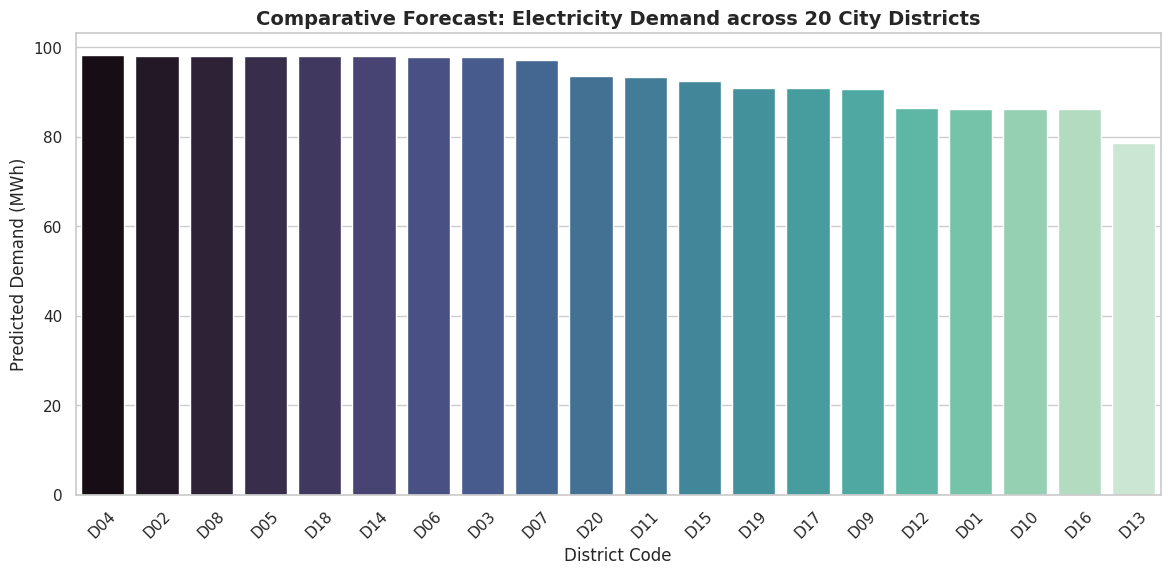

In [6]:
district_ids = [f"D{i:02d}" for i in range(1, 21)]
district_scenarios = []

for d in district_ids:
    scen = {
        "district": d,
        f"district_id_{d}": 1,
        "temperature_c": 27.0,
        "solar_generation_mwh": 80.0,
        "base_electricity_demand_mwh": 100.0 + np.random.uniform(-15, 30),
        "population": int(np.random.uniform(50000, 250000)),
        "grid_capacity_mwh_x": 450.0
    }
    district_scenarios.append(scen)

dist_preds = predict_scenarios(district_scenarios)
dist_df = pd.DataFrame(district_scenarios)
dist_df["predicted_demand_mwh"] = dist_preds
dist_df = dist_df.sort_values(by="predicted_demand_mwh", ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=dist_df, x="district", y="predicted_demand_mwh", palette="mako")
plt.title("Comparative Forecast: Electricity Demand across 20 City Districts", fontsize=14, fontweight="bold")
plt.xlabel("District Code")
plt.ylabel("Predicted Demand (MWh)")
plt.xticks(rotation=45)
plt.show()

### 🌐 Scenario E: Querying Decisera Live REST API directly from Jupyter
Performing predictions by calling the running Decisera backend microservice.

In [7]:
import json
api_url = os.environ.get("BACKEND_URL", "http://backend:8000") + "/api/v1/models/predict"

payload = {
    "model_id": "model_custom_randomforestregressor_20260907151324",
    "data": {
        "base_electricity_demand_mwh": 135.0,
        "grid_capacity_mwh_x": 500.0,
        "solar_generation_mwh": 160.0,
        "temperature_c": 31.0,
        "population": 180000
    }
}

try:
    resp = requests.post(api_url, json=payload, timeout=5)
    print(f"API Status Code: {resp.status_code}")
    print("API Response:", json.dumps(resp.json(), indent=2))
except Exception as e:
    print(f"API request note: {e}")

API Status Code: 200
API Response: {
  "predictions": [
    {
      "prediction": 106.7126401670956,
      "confidence": null,
      "probabilities": null,
      "model": "RandomForestRegressor"
    }
  ]
}
